In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.0 MB/s eta 0:00:00


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/GuardianEye/datasets'))

['stopline', 'vehicle', 'wrongside_driving', 'helmet', 'accident', 'triple_riding', 'illegal_parking', 'redlight', 'license_plate', 'seatbelt']


In [ ]:
from ultralytics import YOLO
import os

# Set base path
base = '/content/drive/MyDrive/GuardianEye/datasets'

# All datasets to train
datasets = {
    'helmet': f'{base}/helmet/data.yaml',
    'vehicle': f'{base}/vehicle/data.yaml',
    'seatbelt': f'{base}/seatbelt/data.yaml',
    'triple_riding': f'{base}/triple_riding/data.yaml',
    'redlight': f'{base}/redlight/data.yaml',
    'stopline': f'{base}/stopline/data.yaml',
    'illegal_parking': f'{base}/illegal_parking/data.yaml',
    'wrong_side': f'{base}/wrong_side/data.yaml',
    'license_plate': f'{base}/license_plate/data.yaml',
    'accident': f'{base}/accident/data.yaml',
}

# Train each model
for name, yaml in datasets.items():
    print(f"\n🚀 Training {name} model...")
    model = YOLO('yolov8n.pt')
    model.train(
        data=yaml,
        epochs=50,
        imgsz=640,
        batch=16,
        name=f'{name}_model',
        project='/content/drive/MyDrive/GuardianEye/models'
    )
    print(f"✅ {name} model done!")

print("\n🎉 ALL MODELS TRAINED!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Training helmet model...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GuardianEye/datasets/helmet/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/drive/MyDrive/GuardianEye/datasets/helmet/train/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [ ]:
import os

helmet_path = '/content/drive/MyDrive/GuardianEye/datasets/helmet'
for root, dirs, files in os.walk(helmet_path):
    print(root)

/content/drive/MyDrive/GuardianEye/datasets/helmet
/content/drive/MyDrive/GuardianEye/datasets/helmet/test
/content/drive/MyDrive/GuardianEye/datasets/helmet/test/images
/content/drive/MyDrive/GuardianEye/datasets/helmet/test/labels
/content/drive/MyDrive/GuardianEye/datasets/helmet/train
/content/drive/MyDrive/GuardianEye/datasets/helmet/train/images


In [ ]:
import os
import shutil

helmet_path = '/content/drive/MyDrive/GuardianEye/datasets/helmet'

# Create valid folder using test folder
os.makedirs(f'{helmet_path}/valid/images', exist_ok=True)
os.makedirs(f'{helmet_path}/valid/labels', exist_ok=True)

# Copy test images to valid folder
for file in os.listdir(f'{helmet_path}/test/images'):
    shutil.copy(
        f'{helmet_path}/test/images/{file}',
        f'{helmet_path}/valid/images/{file}'
    )

# Copy test labels to valid folder
for file in os.listdir(f'{helmet_path}/test/labels'):
    shutil.copy(
        f'{helmet_path}/test/labels/{file}',
        f'{helmet_path}/valid/labels/{file}'
    )

print("✅ Valid folder created!")

✅ Valid folder created!


In [ ]:
yaml_path = '/content/drive/MyDrive/GuardianEye/datasets/helmet/data.yaml'
with open(yaml_path, 'r') as f:
    content = f.read()
print(content)

train: ../train/images
val: ../test/images
test: ../test/images

nc: 2
names: ['With Helmet', 'Without Helmet']

roboflow:
  workspace: bike-helmets
  project: bike-helmet-detection-2vdjo
  version: 2
  license: Public Domain
  url: https://universe.roboflow.com/bike-helmets/bike-helmet-detection-2vdjo/dataset/2


In [ ]:
yaml_content = """train: /content/drive/MyDrive/GuardianEye/datasets/helmet/train/images
val: /content/drive/MyDrive/GuardianEye/datasets/helmet/valid/images
test: /content/drive/MyDrive/GuardianEye/datasets/helmet/test/images

nc: 2
names: ['helmet', 'no_helmet']"""

yaml_path = '/content/drive/MyDrive/GuardianEye/datasets/helmet/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml fixed!")

✅ data.yaml fixed!


In [ ]:
from ultralytics import YOLO

print("🚀 Training Helmet Model...")
model = YOLO('yolov8n.pt')
model.train(
    data='/content/drive/MyDrive/GuardianEye/datasets/helmet/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='helmet_model',
    project='/content/drive/MyDrive/GuardianEye/models'
)
print("✅ Helmet Model Done!")

🚀 Training Helmet Model...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GuardianEye/datasets/helmet/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_model-2, nbs=64, nms=False, opset=Non

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/drive/MyDrive/GuardianEye/datasets/helmet/train/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [ ]:
import os

train_images = '/content/drive/MyDrive/GuardianEye/datasets/helmet/train/images'

files = os.listdir(train_images)
print(f"Total files: {len(files)}")
print("First 5 files:")
print(files[:5])

Total files: 0
First 5 files:
[]


In [ ]:
# Install requirements
from ultralytics import YOLO

# Download pretrained YOLOv8 model
# Already knows: cars, bikes, people,
# trucks, buses and more!
model = YOLO('yolov8n.pt')

# Test it immediately!
results = model.predict(
    source='https://ultralytics.com/images/bus.jpg',
    show=False,
    save=True
)
print("✅ Model working!")
print(f"Detected: {results[0].boxes.cls}")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 44.5ms
Speed: 2.3ms preprocess, 44.5ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
✅ Model working!
Detected: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')


In [ ]:
pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")
workspace = rf.workspace()
print(workspace)

loading Roboflow workspace...
{
  "name": "Deepeshs Workspace",
  "url": "deepeshs-workspace-blpt1",
  "projects": [
    "deepeshs-workspace-blpt1/helmet-detection-ntbfz-ewe7m",
    "deepeshs-workspace-blpt1/helmet-detection-ntbfz-yhlym",
    "deepeshs-workspace-blpt1/vehicle-detection-eckrb-gtemm"
  ]
}


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

workspace = rf.workspace("deepeshs-workspace-blpt1")
projects = workspace.projects()
for p in projects:
    print(p.id)

loading Roboflow workspace...


AttributeError: 'str' object has no attribute 'id'

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

# List all projects
workspace = rf.workspace("deepeshs-workspace-blpt1")
projects = workspace.projects()
print(type(projects))
print(projects)

loading Roboflow workspace...
<class 'list'>
['deepeshs-workspace-blpt1/accident-detection-uaotj-9hhe4', 'deepeshs-workspace-blpt1/helmet-detection-ntbfz-ewe7m', 'deepeshs-workspace-blpt1/illegal-parking-detection-unrl5', 'deepeshs-workspace-blpt1/indian-license-plate-knte7-cnedq', 'deepeshs-workspace-blpt1/seatbelt-detection-lb1ec-3jgks', 'deepeshs-workspace-blpt1/stop-line-jzmgr', 'deepeshs-workspace-blpt1/traffic-red-light-violation-izf63-fmlpo', 'deepeshs-workspace-blpt1/triple-ride-detection-jscpe', 'deepeshs-workspace-blpt1/vehicle-detection-eckrb-gtemm', 'deepeshs-workspace-blpt1/wrong-way-driving-detection-wemhn']


In [ ]:
from roboflow import Roboflow
import json

rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")
workspace = rf.workspace("deepeshs-workspace-blpt1")
projects = workspace.projects()
print(dir(projects[0]))

loading Roboflow workspace...
['__add__', '__class__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mod__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmod__', '__rmul__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'capitalize', 'casefold', 'center', 'count', 'encode', 'endswith', 'expandtabs', 'find', 'format', 'format_map', 'index', 'isalnum', 'isalpha', 'isascii', 'isdecimal', 'isdigit', 'isidentifier', 'islower', 'isnumeric', 'isprintable', 'isspace', 'istitle', 'isupper', 'join', 'ljust', 'lower', 'lstrip', 'maketrans', 'partition', 'removeprefix', 'removesuffix', 'replace', 'rfind', 'rindex', 'rjust', 'rpartition', 'rsplit', 'rstrip', 'split', 'splitlines', 'startswith', 'strip', 'swapcase', 'title', 'translate', 'upper'

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

workspace = rf.workspace("deepeshs-workspace-blpt1")
projects = workspace.projects()
for p in projects:
    print(p)

loading Roboflow workspace...
deepeshs-workspace-blpt1/accident-detection-uaotj-9hhe4
deepeshs-workspace-blpt1/helmet-detection-ntbfz-ewe7m
deepeshs-workspace-blpt1/illegal-parking-detection-unrl5
deepeshs-workspace-blpt1/indian-license-plate-knte7-cnedq
deepeshs-workspace-blpt1/seatbelt-detection-lb1ec-3jgks
deepeshs-workspace-blpt1/stop-line-jzmgr
deepeshs-workspace-blpt1/traffic-red-light-violation-izf63-fmlpo
deepeshs-workspace-blpt1/triple-ride-detection-jscpe
deepeshs-workspace-blpt1/vehicle-detection-eckrb-gtemm
deepeshs-workspace-blpt1/wrong-way-driving-detection-wemhn


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

ws = "deepeshs-workspace-blpt1"

datasets = [
    "accident-detection-uaotj-9hhe4",
    "helmet-detection-ntbfz-ewe7m",
    "illegal-parking-detection-unrl5",
    "indian-license-plate-knte7-cnedq",
    "seatbelt-detection-lb1ec-3jgks",
    "stop-line-jzmgr",
    "traffic-red-light-violation-izf63-fmlpo",
    "triple-ride-detection-jscpe",
    "vehicle-detection-eckrb-gtemm",
    "wrong-way-driving-detection-wemhn"
]

for dataset_name in datasets:
    print(f"\n📥 Downloading {dataset_name}...")
    try:
        project = rf.workspace(ws).project(dataset_name)
        version = project.versions()[0]
        version.download("yolov8")
        print(f"✅ {dataset_name} downloaded!")
    except Exception as e:
        print(f"❌ Error: {dataset_name}: {e}")

print("\n🎉 ALL DATASETS DOWNLOADED!")


📥 Downloading accident-detection-uaotj-9hhe4...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: accident-detection-uaotj-9hhe4: list index out of range

📥 Downloading helmet-detection-ntbfz-ewe7m...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: helmet-detection-ntbfz-ewe7m: list index out of range

📥 Downloading illegal-parking-detection-unrl5...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: illegal-parking-detection-unrl5: list index out of range

📥 Downloading indian-license-plate-knte7-cnedq...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: indian-license-plate-knte7-cnedq: list index out of range

📥 Downloading seatbelt-detection-lb1ec-3jgks...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: seatbelt-detection-lb1ec-3jgks: list index out of range

📥 Downloading stop-line-jzmgr...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: stop-line-jzmgr: list index out of ra

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

ws = "deepeshs-workspace-blpt1"

datasets = [
    "accident-detection-uaotj-9hhe4",
    "helmet-detection-ntbfz-ewe7m",
    "illegal-parking-detection-unrl5",
    "indian-license-plate-knte7-cnedq",
    "seatbelt-detection-lb1ec-3jgks",
    "stop-line-jzmgr",
    "traffic-red-light-violation-izf63-fmlpo",
    "triple-ride-detection-jscpe",
    "vehicle-detection-eckrb-gtemm",
    "wrong-way-driving-detection-wemhn"
]

for dataset_name in datasets:
    print(f"\n📥 Downloading {dataset_name}...")
    try:
        project = rf.workspace(ws).project(dataset_name)
        version = project.version(1)
        version.download("yolov8")
        print(f"✅ {dataset_name} downloaded!")
    except Exception as e:
        print(f"❌ Error: {dataset_name}: {e}")

print("\n🎉 ALL DATASETS DOWNLOADED!")


📥 Downloading accident-detection-uaotj-9hhe4...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: accident-detection-uaotj-9hhe4: Version number 1 is not found.

📥 Downloading helmet-detection-ntbfz-ewe7m...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: helmet-detection-ntbfz-ewe7m: Version number 1 is not found.

📥 Downloading illegal-parking-detection-unrl5...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: illegal-parking-detection-unrl5: Version number 1 is not found.

📥 Downloading indian-license-plate-knte7-cnedq...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: indian-license-plate-knte7-cnedq: Version number 1 is not found.

📥 Downloading seatbelt-detection-lb1ec-3jgks...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: seatbelt-detection-lb1ec-3jgks: Version number 1 is not found.

📥 Downloading stop-line-jzmgr...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: st

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

ws = "deepeshs-workspace-blpt1"

datasets = [
    "accident-detection-uaotj-9hhe4",
    "helmet-detection-ntbfz-ewe7m",
    "illegal-parking-detection-unrl5",
    "indian-license-plate-knte7-cnedq",
    "seatbelt-detection-lb1ec-3jgks",
    "stop-line-jzmgr",
    "traffic-red-light-violation-izf63-fmlpo",
    "triple-ride-detection-jscpe",
    "vehicle-detection-eckrb-gtemm",
    "wrong-way-driving-detection-wemhn"
]

for dataset_name in datasets:
    try:
        project = rf.workspace(ws).project(dataset_name)
        versions = project.versions()
        print(f"{dataset_name}: versions = {versions}")
    except Exception as e:
        print(f"❌ {dataset_name}: {e}")

loading Roboflow workspace...
loading Roboflow project...
accident-detection-uaotj-9hhe4: versions = []
loading Roboflow workspace...
loading Roboflow project...
helmet-detection-ntbfz-ewe7m: versions = []
loading Roboflow workspace...
loading Roboflow project...
illegal-parking-detection-unrl5: versions = []
loading Roboflow workspace...
loading Roboflow project...
indian-license-plate-knte7-cnedq: versions = []
loading Roboflow workspace...
loading Roboflow project...
seatbelt-detection-lb1ec-3jgks: versions = []
loading Roboflow workspace...
loading Roboflow project...
stop-line-jzmgr: versions = []
loading Roboflow workspace...
loading Roboflow project...
traffic-red-light-violation-izf63-fmlpo: versions = []
loading Roboflow workspace...
loading Roboflow project...
triple-ride-detection-jscpe: versions = []
loading Roboflow workspace...
loading Roboflow project...
vehicle-detection-eckrb-gtemm: versions = []
loading Roboflow workspace...
loading Roboflow project...
wrong-way-drivi

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

ws = "deepeshs-workspace-blpt1"

datasets = [
    "accident-detection-uaotj-9hhe4",
    "helmet-detection-ntbfz-ewe7m",
    "illegal-parking-detection-unrl5",
    "indian-license-plate-knte7-cnedq",
    "seatbelt-detection-lb1ec-3jgks",
    "stop-line-jzmgr",
    "traffic-red-light-violation-izf63-fmlpo",
    "triple-ride-detection-jscpe",
    "vehicle-detection-eckrb-gtemm",
    "wrong-way-driving-detection-wemhn"
]

for dataset_name in datasets:
    print(f"\n📥 Downloading {dataset_name}...")
    try:
        project = rf.workspace(ws).project(dataset_name)
        version = project.version(1)
        version.download("yolov8")
        print(f"✅ {dataset_name} downloaded!")
    except Exception as e:
        print(f"❌ Error: {dataset_name}: {e}")

print("\n🎉 ALL DATASETS DOWNLOADED!")


📥 Downloading accident-detection-uaotj-9hhe4...
loading Roboflow workspace...
loading Roboflow project...
❌ Error: accident-detection-uaotj-9hhe4: {"error":"yolov8 is an invalid format for project type classification. Please use one of: folder, clip."}

📥 Downloading helmet-detection-ntbfz-ewe7m...
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to helmet-detection-1 in yolov8:: 100%|██████████| 9257/9257 [00:05<00:00, 1731.56it/s]


✅ helmet-detection-ntbfz-ewe7m downloaded!

📥 Downloading illegal-parking-detection-unrl5...
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Illegal-Parking-Detection-1 in yolov8:: 100%|██████████| 1642/1642 [00:00<00:00, 3293.30it/s]


✅ illegal-parking-detection-unrl5 downloaded!

📥 Downloading indian-license-plate-knte7-cnedq...
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format


...

loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Vehicle-detection-1 in yolov8:: 100%|██████████| 5486/5486 [00:00<00:00, 5769.92it/s]


✅ vehicle-detection-eckrb-gtemm downloaded!

📥 Downloading wrong-way-driving-detection-wemhn...
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 82.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Wrong-Way-Driving-Detection-1 in yolov8:: 100%|██████████| 1220/1220 [00:00<00:00, 2721.99it/s]

✅ wrong-way-driving-detection-wemhn downloaded!

🎉 ALL DATASETS DOWNLOADED!


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")

project = rf.workspace("deepeshs-workspace-blpt1").project("accident-detection-uaotj-9hhe4")
version = project.version(1)

# Try different format
version.download("folder")
print("✅ Accident downloaded!")

loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 6.0%
Version export complete for folder format



Extracting Dataset Version Zip to Accident-Detection-1 in folder:: 100%|██████████| 966/966 [00:00<00:00, 1945.37it/s]


✅ Accident downloaded!


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'bus.jpg', 'Traffic-Red-Light-Violation-1', 'Vehicle-detection-1', 'Illegal-Parking-Detection-1', 'Wrong-Way-Driving-Detection-1', 'Indian-License-Plate-1', 'stop-line-1', 'Triple-Ride-Detection-1', 'helmet-detection-1', 'yolov8n.pt', 'runs', 'seatbelt-detection-1', 'Accident-Detection-1', 'yolo26n.pt', 'sample_data']


In [ ]:
from ultralytics import YOLO
import os

# All datasets with correct folder names
datasets = {
    'accident': '/content/Accident-Detection-1/data.yaml',
    'helmet': '/content/helmet-detection-1/data.yaml',
    'illegal_parking': '/content/Illegal-Parking-Detection-1/data.yaml',
    'license_plate': '/content/Indian-License-Plate-1/data.yaml',
    'seatbelt': '/content/seatbelt-detection-1/data.yaml',
    'stopline': '/content/stop-line-1/data.yaml',
    'redlight': '/content/Traffic-Red-Light-Violation-1/data.yaml',
    'triple_ride': '/content/Triple-Ride-Detection-1/data.yaml',
    'vehicle': '/content/Vehicle-detection-1/data.yaml',
    'wrong_way': '/content/Wrong-Way-Driving-Detection-1/data.yaml',
}

# Train each model
for name, yaml in datasets.items():
    if os.path.exists(yaml):
        print(f"\n🚀 Training {name} model...")
        model = YOLO('yolov8n.pt')
        model.train(
            data=yaml,
            epochs=50,
            imgsz=640,
            batch=16,
            name=f'{name}_model',
            project='/content/drive/MyDrive/GuardianEye/models'
        )
        print(f"✅ {name} done!")
    else:
        print(f"❌ yaml not found: {yaml}")

print("\n🎉 ALL MODELS TRAINED!")

❌ yaml not found: /content/Accident-Detection-1/data.yaml

🚀 Training helmet model...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_m

KeyboardInterrupt: 

In [ ]:
import os
print(os.listdir('/content/Accident-Detection-1'))

['valid', 'train', 'README.roboflow.txt', 'test']


In [ ]:
import os
print(os.listdir('/content/Accident-Detection-1/train'))

['Accident', 'Non Accident']


In [ ]:
# Create data.yaml for accident dataset
yaml_content = """train: /content/Accident-Detection-1/train
val: /content/Accident-Detection-1/valid
test: /content/Accident-Detection-1/test

nc: 2
names: ['Accident', 'Non Accident']"""

with open('/content/Accident-Detection-1/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml created!")

✅ data.yaml created!


In [ ]:
from ultralytics import YOLO
import os

datasets = {
    'accident': '/content/Accident-Detection-1/data.yaml',
    'helmet': '/content/helmet-detection-1/data.yaml',
    'illegal_parking': '/content/Illegal-Parking-Detection-1/data.yaml',
    'license_plate': '/content/Indian-License-Plate-1/data.yaml',
    'seatbelt': '/content/seatbelt-detection-1/data.yaml',
    'stopline': '/content/stop-line-1/data.yaml',
    'redlight': '/content/Traffic-Red-Light-Violation-1/data.yaml',
    'triple_ride': '/content/Triple-Ride-Detection-1/data.yaml',
    'vehicle': '/content/Vehicle-detection-1/data.yaml',
    'wrong_way': '/content/Wrong-Way-Driving-Detection-1/data.yaml',
}

for name, yaml in datasets.items():
    if os.path.exists(yaml):
        print(f"\n🚀 Training {name}...")
        model = YOLO('yolov8n.pt')
        model.train(
            data=yaml,
            epochs=20,
            imgsz=640,
            batch=16,
            name=f'{name}_model',
            project='/content/drive/MyDrive/GuardianEye/models'
        )
        print(f"✅ {name} done!")
    else:
        print(f"❌ yaml not found: {yaml}")

print("\n🎉 ALL 10 MODELS TRAINING DONE!")


🚀 Training accident...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Accident-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=accident_model, nbs=64, nms=False, opset=None, optimize=False, optim

Mean of empty slice.
invalid value encountered in divide



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      3.62G          0      82.51          0          0        640: 100% ━━━━━━━━━━━━ 43/43 3.7it/s 11.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.4it/s 1.3s
                   all        194          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


Mean of empty slice.
invalid value encountered in divide



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      3.63G          0      68.94          0          0        640: 100% ━━━━━━━━━━━━ 43/43 3.1it/s 13.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.5it/s 2.0s
                   all        194          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20       3.7G          0      1.861          0          0        640: 100% ━━━━━━━━━━━━ 43/43 3.5it/s 12.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 6.2it/s 1.1s
                   all        194          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


Mean of empty slice.
invalid value encountered in divide



20 epochs completed in 0.086 hours.
Optimizer stripped from /content/drive/MyDrive/GuardianEye/models/accident_model/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/GuardianEye/models/accident_model/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/GuardianEye/models/accident_model/weights/best.pt...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.7it/s 1.9s


Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.


                   all        194          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.3ms preprocess, 4.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/drive/MyDrive/GuardianEye/models/accident_model
✅ accident done!

🚀 Training helmet...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, 

In [ ]:
import os

models_path = '/content/drive/MyDrive/GuardianEye/models'

expected_models = [
    'accident_model',
    'helmet_model',
    'illegal_parking_model',
    'license_plate_model',
    'seatbelt_model',
    'stopline_model',
    'redlight_model',
    'triple_ride_model',
    'vehicle_model',
    'wrong_way_model'
]

print("🔍 Checking all models...\n")

for model in expected_models:
    model_path = f'{models_path}/{model}/weights/best.pt'
    if os.path.exists(model_path):
        print(f"✅ {model} = TRAINED!")
    else:
        print(f"❌ {model} = MISSING!")

print("\n✅ Check complete!")

🔍 Checking all models...

❌ accident_model = MISSING!
❌ helmet_model = MISSING!
❌ illegal_parking_model = MISSING!
❌ license_plate_model = MISSING!
❌ seatbelt_model = MISSING!
❌ stopline_model = MISSING!
❌ redlight_model = MISSING!
❌ triple_ride_model = MISSING!
❌ vehicle_model = MISSING!
❌ wrong_way_model = MISSING!

✅ Check complete!


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

models_path = '/content/drive/MyDrive/GuardianEye/models'
print(os.listdir(models_path))

Mounted at /content/drive
['helmet_model', 'accident_model', 'helmet_model-2', 'illegal_parking_model', 'license_plate_model', 'seatbelt_model', 'stopline_model', 'redlight_model', 'triple_ride_model', 'vehicle_model', 'wrong_way_model']


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
from ultralytics import YOLO
import os
import json
from datetime import datetime

# Load all models
models_path = '/content/drive/MyDrive/GuardianEye/models'

print("Loading all models...")

models = {
    'helmet': YOLO(f'{models_path}/helmet_model/weights/best.pt'),
    'accident': YOLO(f'{models_path}/accident_model/weights/best.pt'),
    'illegal_parking': YOLO(f'{models_path}/illegal_parking_model/weights/best.pt'),
    'license_plate': YOLO(f'{models_path}/license_plate_model/weights/best.pt'),
    'seatbelt': YOLO(f'{models_path}/seatbelt_model/weights/best.pt'),
    'stopline': YOLO(f'{models_path}/stopline_model/weights/best.pt'),
    'redlight': YOLO(f'{models_path}/redlight_model/weights/best.pt'),
    'triple_ride': YOLO(f'{models_path}/triple_ride_model/weights/best.pt'),
    'vehicle': YOLO(f'{models_path}/vehicle_model/weights/best.pt'),
    'wrong_way': YOLO(f'{models_path}/wrong_way_model/weights/best.pt'),
}

print("✅ All models loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading all models...
✅ All models loaded successfully!


In [ ]:
import cv2
import os
import json
from datetime import datetime

# Create evidence folder
evidence_path = '/content/drive/MyDrive/GuardianEye/evidence'
os.makedirs(evidence_path, exist_ok=True)

def detect_violations(image_path):
    # Read image
    image = cv2.imread(image_path)
    violations = []

    # Run each model on image
    for model_name, model in models.items():
        results = model(image_path, conf=0.5)

        for result in results:
            boxes = result.boxes
            if boxes is not None and len(boxes) > 0:
                for box in boxes:
                    # Get violation details
                    confidence = float(box.conf[0])
                    class_id = int(box.cls[0])
                    class_name = result.names[class_id]

                    # Draw box on image
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
                    cv2.putText(image,
                        f'{model_name}: {class_name} {confidence:.2f}',
                        (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0,255,0), 2)

                    # Save violation info
                    violations.append({
                        'type': model_name,
                        'class': class_name,
                        'confidence': confidence,
                        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                    })

    # Save evidence image
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    evidence_img = f'{evidence_path}/violation_{timestamp}.jpg'
    cv2.imwrite(evidence_img, image)

    # Save JSON
    json_file = f'{evidence_path}/violation_{timestamp}.json'
    with open(json_file, 'w') as f:
        json.dump(violations, f, indent=4)

    print(f"✅ Found {len(violations)} violations!")
    print(f"📸 Evidence saved: {evidence_img}")
    print(f"📄 JSON saved: {json_file}")

    return violations, evidence_img

print("✅ Detection function ready!")

✅ Detection function ready!


In [ ]:
# Download a test traffic image
import urllib.request

# Download Indian traffic image
urllib.request.urlretrieve(
    'https://upload.wikimedia.org/wikipedia/commons/thumb/1/1f/20131023_bangalore_traffic.jpg/1280px-20131023_bangalore_traffic.jpg',
    'test_traffic.jpg'
)
print("✅ Test image downloaded!")

# Run detection on it
violations, evidence_img = detect_violations('test_traffic.jpg')

# Show results
print("\n📋 Violations Found:")
for v in violations:
    print(f"→ {v['type']}: {v['class']} ({v['confidence']:.2f})")

HTTPError: HTTP Error 403: Forbidden

In [ ]:
# Download different test image
import urllib.request

urllib.request.urlretrieve(
    'https://ultralytics.com/images/bus.jpg',
    'test_traffic.jpg'
)
print("✅ Test image downloaded!")

# Run detection
violations, evidence_img = detect_violations('test_traffic.jpg')

# Show results
print("\n📋 Violations Found:")
for v in violations:
    print(f"→ {v['type']}: {v['class']} ({v['confidence']:.2f})")

✅ Test image downloaded!

image 1/1 /content/test_traffic.jpg: 640x480 2 drivers, 1 no-helmet, 403.0ms
Speed: 16.0ms preprocess, 403.0ms inference, 35.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/test_traffic.jpg: 640x480 (no detections), 274.4ms
Speed: 6.4ms preprocess, 274.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/test_traffic.jpg: 640x480 (no detections), 265.2ms
Speed: 6.2ms preprocess, 265.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/test_traffic.jpg: 640x480 (no detections), 259.4ms
Speed: 7.3ms preprocess, 259.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/test_traffic.jpg: 640x480 (no detections), 165.1ms
Speed: 3.6ms preprocess, 165.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/test_traffic.jpg: 640x480 1 stop-line, 187.5ms
Speed: 4.4ms preprocess, 187.5ms inference, 0.9ms post

In [ ]:
import urllib.request

# Indian traffic images
urls = [
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3b/Delhi_traffic.jpg/1280px-Delhi_traffic.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8b/India_traffic.jpg/1280px-India_traffic.jpg'
]

downloaded = False
for url in urls:
    try:
        urllib.request.urlretrieve(url, 'indian_traffic.jpg')
        print("✅ Image downloaded!")
        downloaded = True
        break
    except:
        continue

if not downloaded:
    print("❌ Try uploading manually!")

❌ Try uploading manually!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg



image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg: 640x384 5 drivers, 2 helmets, 159.7ms
Speed: 2.9ms preprocess, 159.7ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg: 640x384 (no detections), 146.5ms
Speed: 2.9ms preprocess, 146.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg: 640x384 (no detections), 146.3ms
Speed: 4.1ms preprocess, 146.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg: 640x384 (no detections), 147.1ms
Speed: 2.9ms preprocess, 147.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg: 640x384 (no detections), 157.7ms
Speed: 2.8ms preprocess, 157.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

imag

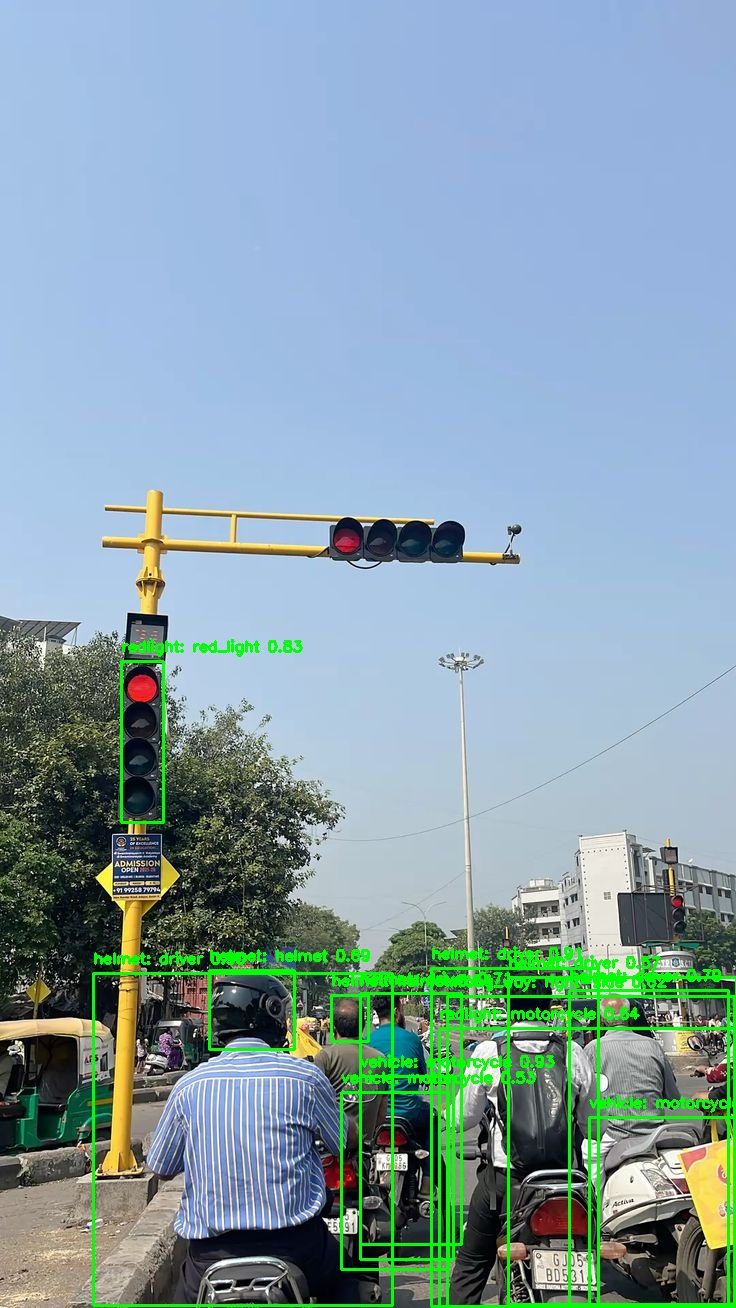

In [ ]:
filename = list(uploaded.keys())[0]
violations, evidence_img = detect_violations(filename)

from IPython.display import Image as IPImage
IPImage(evidence_img)

In [ ]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 24.5 MB/s eta 0:00:00


In [ ]:
import easyocr

# Initialize OCR
reader = easyocr.Reader(['en'])
print("✅ OCR Ready!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ OCR Ready!


In [ ]:
def read_license_plate(image_path, box):
    # Crop license plate area
    image = cv2.imread(image_path)
    x1, y1, x2, y2 = box
    plate_crop = image[y1:y2, x1:x2]

    # Save cropped plate
    cv2.imwrite('plate_crop.jpg', plate_crop)

    # Read text from plate
    results = reader.readtext('plate_crop.jpg')

    plate_text = ""
    for (bbox, text, confidence) in results:
        if confidence > 0.3:
            plate_text += text + " "

    return plate_text.strip()

print("✅ License plate reader ready!")

✅ License plate reader ready!


In [ ]:
def detect_with_plate(image_path):
    violations, evidence_img = detect_violations(image_path)

    # Read plates for each violation
    plate_model = models['license_plate']
    results = plate_model(image_path)

    plates = []
    for result in results:
        if result.boxes is not None:
            for box in result.boxes:
                coords = list(map(int, box.xyxy[0]))
                plate = read_license_plate(image_path, coords)
                if plate:
                    plates.append(plate)
                    print(f"🔢 Plate found: {plate}")

    return violations, plates, evidence_img

print("✅ Full detection system ready!")

✅ Full detection system ready!


In [ ]:
# Test full system with license plate
violations, plates, evidence_img = detect_with_plate('indian_traffic.jpg')

# Show complete results
print("\n📋 COMPLETE DETECTION REPORT")
print("="*40)
print(f"\n🚨 Violations Found: {len(violations)}")
for v in violations:
    print(f"→ {v['type']}: {v['class']} ({v['confidence']:.2f})")

print(f"\n🔢 License Plates Found: {len(plates)}")
for p in plates:
    print(f"→ Plate: {p}")

print("\n📸 Evidence saved to Drive!")
print("="*40)

# Show image with detections
from IPython.display import Image as IPImage
IPImage(evidence_img)

FileNotFoundError: indian_traffic.jpg does not exist

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg



image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg: 640x384 5 drivers, 2 helmets, 267.1ms
Speed: 11.3ms preprocess, 267.1ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg: 640x384 (no detections), 317.8ms
Speed: 6.8ms preprocess, 317.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg: 640x384 (no detections), 301.9ms
Speed: 3.8ms preprocess, 301.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg: 640x384 (no detections), 364.4ms
Speed: 3.9ms preprocess, 364.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg: 640x384 (no detections), 233.1ms
Speed: 3.7ms preprocess, 233.1ms inference, 0.9ms postprocess per image at shape (

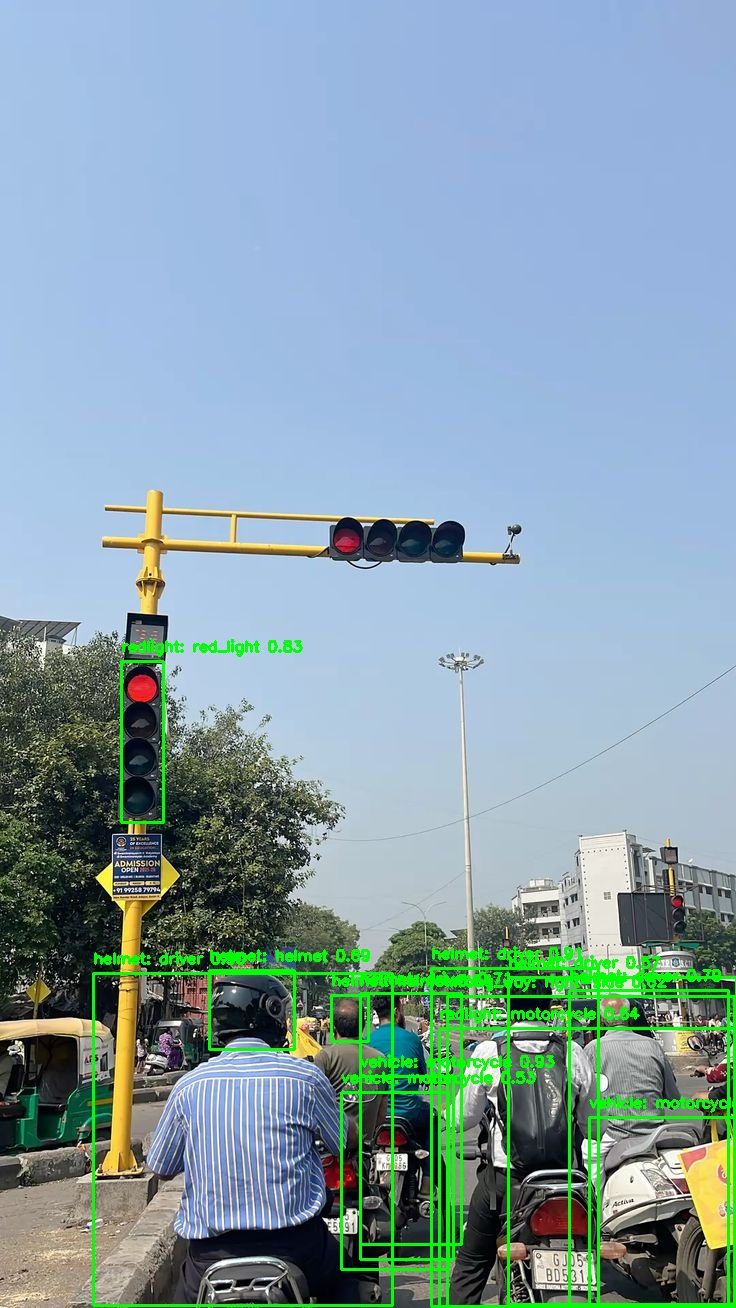

In [ ]:
# Test full system
violations, plates, evidence_img = detect_with_plate(filename)

# Show results
print("\n📋 COMPLETE DETECTION REPORT")
print("="*40)
print(f"\n🚨 Violations Found: {len(violations)}")
for v in violations:
    print(f"→ {v['type']}: {v['class']} ({v['confidence']:.2f})")

print(f"\n🔢 License Plates Found: {len(plates)}")
for p in plates:
    print(f"→ Plate: {p}")

print("\n📸 Evidence saved to Drive!")
print("="*40)

# Show image
from IPython.display import Image as IPImage
IPImage(evidence_img)

In [ ]:
# Download clear number plate image
import urllib.request

urllib.request.urlretrieve(
    'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/DL1234.jpg/320px-DL1234.jpg',
    'plate_test.jpg'
)

# Test plate reading directly
results = reader.readtext('plate_test.jpg')
for (bbox, text, confidence) in results:
    print(f"📋 Text: {text} | Confidence: {confidence:.2f}")

HTTPError: HTTP Error 403: Forbidden

In [ ]:
from google.colab import files
uploaded = files.upload()
plate_image = list(uploaded.keys())[0]
print(f"✅ Uploaded: {plate_image}")

# Test plate reading
results = reader.readtext(plate_image)
print("\n🔢 Plate Detection Results:")
for (bbox, text, confidence) in results:
    if confidence > 0.3:
        print(f"→ Text: {text} | Confidence: {confidence:.2f}")

Saving WhatsApp Image 2026-06-17 at 11.00.54 PM.jpeg to WhatsApp Image 2026-06-17 at 11.00.54 PM.jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 11.00.54 PM.jpeg


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



🔢 Plate Detection Results:
→ Text: Engcavino | Confidence: 0.49
→ Text: HONDA | Confidence: 1.00
→ Text: AP39S | Confidence: 0.41
→ Text: 8882 | Confidence: 0.60


In [ ]:
def save_final_json(violations, plates, image_path):
    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "image": image_path,
        "violations": violations,
        "license_plates": plates,
        "alert_sent": True,
        "severity": "HIGH" if len(violations) > 2 else "LOW"
    }

    json_path = '/content/drive/MyDrive/GuardianEye/evidence/final_output.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)

    print("✅ JSON saved for web team!")
    print(json.dumps(output, indent=4))

    return output

save_final_json(violations, plates, filename)

✅ JSON saved for web team!
{
    "timestamp": "2026-06-18 06:08:50",
    "camera_id": "CAM_001",
    "location": "Delhi, India",
    "image": "WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg",
    "violations": [
        {
            "type": "helmet",
            "class": "driver",
            "confidence": 0.9067636132240295,
            "time": "2026-06-18 05:54:51"
        },
        {
            "type": "helmet",
            "class": "driver",
            "confidence": 0.9030369520187378,
            "time": "2026-06-18 05:54:51"
        },
        {
            "type": "helmet",
            "class": "driver",
            "confidence": 0.7889295816421509,
            "time": "2026-06-18 05:54:51"
        },
        {
            "type": "helmet",
            "class": "driver",
            "confidence": 0.705954909324646,
            "time": "2026-06-18 05:54:51"
        },
        {
            "type": "helmet",
            "class": "helmet",
            "confidence": 0.6891279

{'timestamp': '2026-06-18 06:08:50',
 'camera_id': 'CAM_001',
 'location': 'Delhi, India',
 'image': 'WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg',
 'violations': [{'type': 'helmet',
   'class': 'driver',
   'confidence': 0.9067636132240295,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.9030369520187378,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.7889295816421509,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.705954909324646,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'helmet',
   'confidence': 0.6891279220581055,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.5736933350563049,
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'helmet',
   'confidence': 0.5438708066940308,
   'time': '2026-06-18 05:54:51'},
  {'type': 'redlight',
   'c

In [ ]:
# Severity scores for each violation
violation_scores = {
    'helmet': {
        'no-helmet': 8,
        'helmet': 0,
        'driver': 5
    },
    'accident': {
        'Accident': 10,
        'Non Accident': 0
    },
    'illegal_parking': {
        'illegal-parking': 4,
        'parking': 2
    },
    'license_plate': {
        'license-plate': 0
    },
    'seatbelt': {
        'no-seatbelt': 7,
        'seatbelt': 0
    },
    'stopline': {
        'stop-line': 6
    },
    'redlight': {
        'red_light': 9,
        'motorcycle': 5
    },
    'triple_ride': {
        'triple-ride': 8
    },
    'vehicle': {
        'motorcycle': 3,
        'car': 3,
        'truck': 3
    },
    'wrong_way': {
        'wrong-side': 10,
        'right-side': 0
    }
}

def get_severity_label(score):
    if score >= 9:
        return "🔴 CRITICAL"
    elif score >= 7:
        return "🟠 HIGH"
    elif score >= 4:
        return "🟡 MEDIUM"
    else:
        return "🟢 LOW"

def save_final_json_with_scores(violations, plates, image_path):

    # Add scores to violations
    scored_violations = []
    total_score = 0

    for v in violations:
        vtype = v['type']
        vclass = v['class']

        # Get score
        score = violation_scores.get(vtype, {}).get(vclass, 3)
        total_score += score

        scored_violations.append({
            'type': vtype,
            'class': vclass,
            'confidence': round(v['confidence'], 2),
            'score': score,
            'severity': get_severity_label(score),
            'time': v['time']
        })

    # Overall severity
    if total_score >= 20:
        overall = "🔴 CRITICAL"
    elif total_score >= 10:
        overall = "🟠 HIGH"
    elif total_score >= 5:
        overall = "🟡 MEDIUM"
    else:
        overall = "🟢 LOW"

    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "image": image_path,
        "total_score": total_score,
        "overall_severity": overall,
        "violations": scored_violations,
        "license_plates": plates,
        "alert_sent": True
    }

    json_path = '/content/drive/MyDrive/GuardianEye/evidence/final_output.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)

    print("✅ JSON with scores saved!")
    print(f"\n📊 VIOLATION REPORT")
    print("="*40)
    for v in scored_violations:
        print(f"→ {v['type']}: {v['class']} | Score: {v['score']}/10 | {v['severity']}")
    print(f"\n🎯 Total Score: {total_score}")
    print(f"⚠️ Overall: {overall}")
    print("="*40)

    return output

# Run it!
save_final_json_with_scores(violations, plates, filename)

✅ JSON with scores saved!

📊 VIOLATION REPORT
→ helmet: driver | Score: 5/10 | 🟡 MEDIUM
→ helmet: driver | Score: 5/10 | 🟡 MEDIUM
→ helmet: driver | Score: 5/10 | 🟡 MEDIUM
→ helmet: driver | Score: 5/10 | 🟡 MEDIUM
→ helmet: helmet | Score: 0/10 | 🟢 LOW
→ helmet: driver | Score: 5/10 | 🟡 MEDIUM
→ helmet: helmet | Score: 0/10 | 🟢 LOW
→ redlight: red_light | Score: 9/10 | 🔴 CRITICAL
→ redlight: motorcycle | Score: 5/10 | 🟡 MEDIUM
→ vehicle: motorcycle | Score: 3/10 | 🟢 LOW
→ vehicle: motorcycle | Score: 3/10 | 🟢 LOW
→ vehicle: motorcycle | Score: 3/10 | 🟢 LOW
→ wrong_way: right-side | Score: 0/10 | 🟢 LOW

🎯 Total Score: 48
⚠️ Overall: 🔴 CRITICAL


{'timestamp': '2026-06-18 06:12:46',
 'camera_id': 'CAM_001',
 'location': 'Delhi, India',
 'image': 'WhatsApp Image 2026-06-17 at 10.41.09 PM (1).jpeg',
 'total_score': 48,
 'overall_severity': '🔴 CRITICAL',
 'violations': [{'type': 'helmet',
   'class': 'driver',
   'confidence': 0.91,
   'score': 5,
   'severity': '🟡 MEDIUM',
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.9,
   'score': 5,
   'severity': '🟡 MEDIUM',
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.79,
   'score': 5,
   'severity': '🟡 MEDIUM',
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.71,
   'score': 5,
   'severity': '🟡 MEDIUM',
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'helmet',
   'confidence': 0.69,
   'score': 0,
   'severity': '🟢 LOW',
   'time': '2026-06-18 05:54:51'},
  {'type': 'helmet',
   'class': 'driver',
   'confidence': 0.57,


In [ ]:
# Read and print saved JSON
import json

json_path = '/content/drive/MyDrive/GuardianEye/evidence/final_output.json'
with open(json_path, 'r') as f:
    data = json.load(f)

print("📊 COMPLETE VIOLATION REPORT")
print("="*40)
print(f"📅 Time: {data['timestamp']}")
print(f"📍 Location: {data['location']}")
print(f"📷 Camera: {data['camera_id']}")
print(f"\n🚨 Violations Found: {len(data['violations'])}")
print("-"*40)

for v in data['violations']:
    print(f"→ {v['type'].upper()}: {v['class']}")
    print(f"   Score: {v['score']}/10 | {v['severity']}")
    print(f"   Confidence: {v['confidence']}")
    print()

print("-"*40)
print(f"🎯 Total Score: {data['total_score']}")
print(f"⚠️ Overall Severity: {data['overall_severity']}")
print(f"🚔 Alert Sent: {data['alert_sent']}")
print(f"🔢 Plates Found: {data['license_plates']}")
print("="*40)

📊 COMPLETE VIOLATION REPORT
📅 Time: 2026-06-18 06:12:46
📍 Location: Delhi, India
📷 Camera: CAM_001

🚨 Violations Found: 13
----------------------------------------
→ HELMET: driver
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.91

→ HELMET: driver
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.9

→ HELMET: driver
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.79

→ HELMET: driver
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.71

→ HELMET: helmet
   Score: 0/10 | 🟢 LOW
   Confidence: 0.69

→ HELMET: driver
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.57

→ HELMET: helmet
   Score: 0/10 | 🟢 LOW
   Confidence: 0.54

→ REDLIGHT: red_light
   Score: 9/10 | 🔴 CRITICAL
   Confidence: 0.83

→ REDLIGHT: motorcycle
   Score: 5/10 | 🟡 MEDIUM
   Confidence: 0.64

→ VEHICLE: motorcycle
   Score: 3/10 | 🟢 LOW
   Confidence: 0.93

→ VEHICLE: motorcycle
   Score: 3/10 | 🟢 LOW
   Confidence: 0.56

→ VEHICLE: motorcycle
   Score: 3/10 | 🟢 LOW
   Confidence: 0.53

→ WRONG_WAY: right-side
   Score: 0/10 | 🟢 LOW
   Confid

In [ ]:
# Upload a accident image
from google.colab import files
uploaded = files.upload()
accident_image = list(uploaded.keys())[0]

# Run only accident model
results = models['accident'](accident_image, conf=0.3)

print("🚨 Accident Detection Results:")
for result in results:
    if result.boxes is not None:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = result.names[class_id]
            confidence = float(box.conf[0])
            print(f"→ {class_name}: {confidence:.2f}")

Saving WhatsApp Image 2026-06-17 at 11.18.36 PM.jpeg to WhatsApp Image 2026-06-17 at 11.18.36 PM.jpeg

image 1/1 /content/WhatsApp Image 2026-06-17 at 11.18.36 PM.jpeg: 640x480 (no detections), 316.7ms
Speed: 15.1ms preprocess, 316.7ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 480)
🚨 Accident Detection Results:


In [ ]:
# Run with lower confidence
results = models['accident'](accident_image, conf=0.1)

print("🚨 Accident Detection Results:")
for result in results:
    if result.boxes is not None and len(result.boxes) > 0:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = result.names[class_id]
            confidence = float(box.conf[0])
            print(f"→ {class_name}: {confidence:.2f}")
    else:
        print("No detections found!")

# Also check what classes model knows
print(f"\nModel classes: {results[0].names}")


image 1/1 /content/WhatsApp Image 2026-06-17 at 11.18.36 PM.jpeg: 640x480 (no detections), 264.0ms
Speed: 9.5ms preprocess, 264.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
🚨 Accident Detection Results:
No detections found!

Model classes: {0: 'Accident', 1: 'Non Accident'}


In [ ]:
from google.colab import files
uploaded = files.upload()
plate_image = list(uploaded.keys())[0]
print(f"✅ Uploaded: {plate_image}")

# Test plate reading
results = reader.readtext(plate_image)
print("\n🔢 Plate Detection Results:")
for (bbox, text, confidence) in results:
    if confidence > 0.3:
        print(f"→ Text: {text} | Confidence: {confidence:.2f}")

Saving WhatsApp Image 2026-06-17 at 11.01.34 PM.jpeg to WhatsApp Image 2026-06-17 at 11.01.34 PM.jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 11.01.34 PM.jpeg

🔢 Plate Detection Results:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


import json
import os
from datetime import datetime

# Repeat offender tracker
offender_file = '/content/drive/MyDrive/GuardianEye/offenders.json'

def check_repeat_offender(plate_number, violation_type):
    # Load existing offenders
    if os.path.exists(offender_file):
        with open(offender_file, 'r') as f:
            offenders = json.load(f)
    else:
        offenders = {}
    
    # Add new violation
    if plate_number not in offenders:
        offenders[plate_number] = []
    
    offenders[plate_number].append({
        'violation': violation_type,
        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })
    
    # Save updated offenders
    with open(offender_file, 'w') as f:
        json.dump(offenders, f, indent=4)
    
    # Check if repeat offender
    count = len(offenders[plate_number])
    
    if count >= 3:
        print(f"🚨 REPEAT OFFENDER ALERT!")
        print(f"🔢 Plate: {plate_number}")
        print(f"📋 Total violations: {count}")
        print(f"⚠️ AUTO CHALLAN GENERATED!")
        return True, count
    else:
        print(f"✅ Plate {plate_number} | Violations: {count}/3")
        return False, count

# Test it!
check_repeat_offender("DL3C1234", "helmet")
check_repeat_offender("DL3C1234", "redlight")
check_repeat_offender("DL3C1234", "wrong_way")

In [ ]:
import json
import os
from datetime import datetime

offender_file = '/content/drive/MyDrive/GuardianEye/offenders.json'

def check_repeat_offender(plate_number, violation_type):
    if os.path.exists(offender_file):
        with open(offender_file, 'r') as f:
            offenders = json.load(f)
    else:
        offenders = {}

    if plate_number not in offenders:
        offenders[plate_number] = []

    offenders[plate_number].append({
        'violation': violation_type,
        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })

    with open(offender_file, 'w') as f:
        json.dump(offenders, f, indent=4)

    count = len(offenders[plate_number])

    if count >= 3:
        print(f"🚨 REPEAT OFFENDER ALERT!")
        print(f"🔢 Plate: {plate_number}")
        print(f"📋 Total violations: {count}")
        print(f"⚠️ AUTO CHALLAN GENERATED!")
        return True, count
    else:
        print(f"✅ Plate: {plate_number} | Violations: {count}/3")
        return False, count

# Test
check_repeat_offender("DL3C1234", "helmet")
check_repeat_offender("DL3C1234", "redlight")
check_repeat_offender("DL3C1234", "wrong_way")

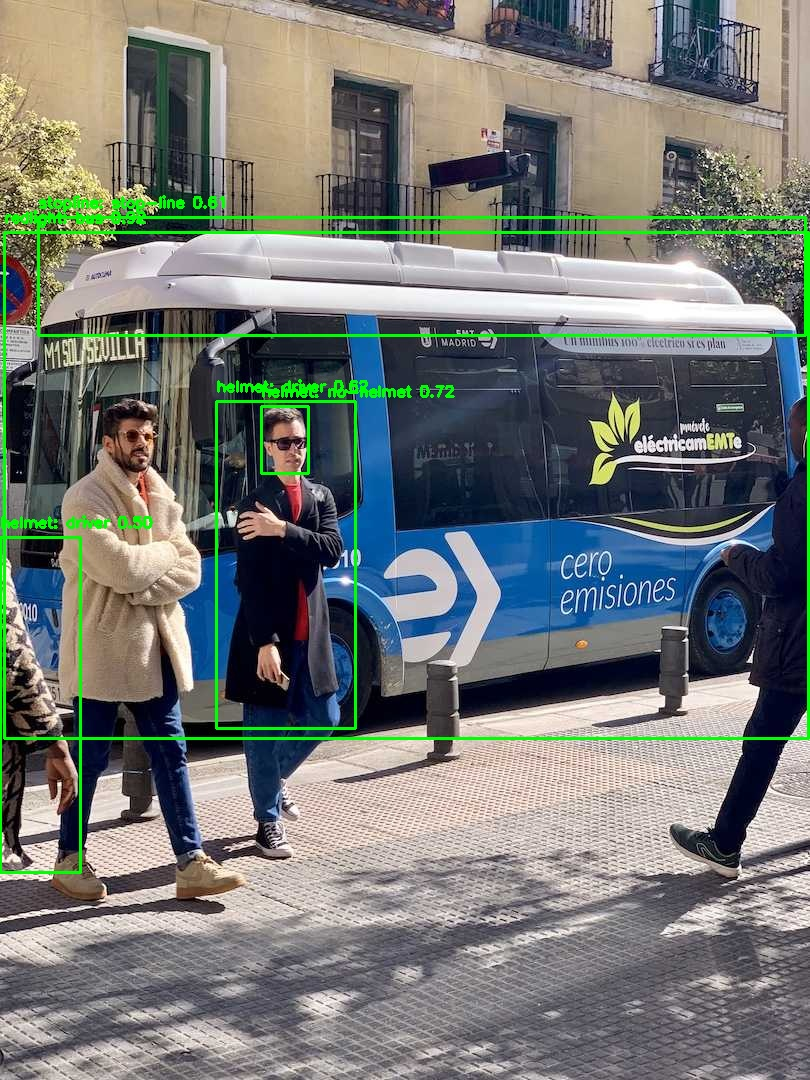

In [ ]:
from IPython.display import Image as IPImage
IPImage(evidence_img)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics easyocr

In [ ]:
from ultralytics import YOLO
import os

models_path = '/content/drive/MyDrive/GuardianEye/models'

models = {
    'helmet': YOLO(f'{models_path}/helmet_model/weights/best.pt'),
    'illegal_parking': YOLO(f'{models_path}/illegal_parking_model/weights/best.pt'),
    'license_plate': YOLO(f'{models_path}/license_plate_model/weights/best.pt'),
    'seatbelt': YOLO(f'{models_path}/seatbelt_model/weights/best.pt'),
    'stopline': YOLO(f'{models_path}/stopline_model/weights/best.pt'),
    'redlight': YOLO(f'{models_path}/redlight_model/weights/best.pt'),
    'triple_ride': YOLO(f'{models_path}/triple_ride_model/weights/best.pt'),
    'vehicle': YOLO(f'{models_path}/vehicle_model/weights/best.pt'),
    'wrong_way': YOLO(f'{models_path}/wrong_way_model/weights/best.pt'),
}

print("✅ All models loaded!")

✅ All models loaded!


In [ ]:
import cv2
import os
import json
import easyocr
from datetime import datetime

# Initialize OCR
reader = easyocr.Reader(['en'])

# Evidence folder
evidence_path = '/content/drive/MyDrive/GuardianEye/evidence'
os.makedirs(evidence_path, exist_ok=True)

# Offender file
offender_file = '/content/drive/MyDrive/GuardianEye/offenders.json'

# Violation scores
violation_scores = {
    'helmet': {'no-helmet': 8, 'helmet': 0, 'driver': 5},
    'accident': {'Accident': 10, 'Non Accident': 0},
    'illegal_parking': {'illegal-parking': 4},
    'seatbelt': {'no-seatbelt': 7, 'seatbelt': 0},
    'stopline': {'stop-line': 6},
    'redlight': {'red_light': 9, 'motorcycle': 5},
    'triple_ride': {'triple-ride': 8},
    'vehicle': {'motorcycle': 3, 'car': 3, 'truck': 3},
    'wrong_way': {'wrong-side': 10, 'right-side': 0}
}

def get_severity_label(score):
    if score >= 9:
        return "🔴 CRITICAL"
    elif score >= 7:
        return "🟠 HIGH"
    elif score >= 4:
        return "🟡 MEDIUM"
    else:
        return "🟢 LOW"

def check_repeat_offender(plate_number, violation_type):
    if os.path.exists(offender_file):
        with open(offender_file, 'r') as f:
            offenders = json.load(f)
    else:
        offenders = {}

    if plate_number not in offenders:
        offenders[plate_number] = []

    offenders[plate_number].append({
        'violation': violation_type,
        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })

    with open(offender_file, 'w') as f:
        json.dump(offenders, f, indent=4)

    count = len(offenders[plate_number])

    if count >= 3:
        print(f"🚨 REPEAT OFFENDER! Plate: {plate_number} | Violations: {count}")
        return True, count
    else:
        print(f"✅ Plate: {plate_number} | Violations: {count}/3")
        return False, count

def detect_violations(image_path):
    image = cv2.imread(image_path)
    violations = []

    for model_name, model in models.items():
        results = model(image_path, conf=0.5)
        for result in results:
            if result.boxes is not None and len(result.boxes) > 0:
                for box in result.boxes:
                    confidence = float(box.conf[0])
                    class_id = int(box.cls[0])
                    class_name = result.names[class_id]
                    score = violation_scores.get(model_name, {}).get(class_name, 3)

                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
                    cv2.putText(image,
                        f'{model_name}: {class_name} {confidence:.2f}',
                        (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0,255,0), 2)

                    violations.append({
                        'type': model_name,
                        'class': class_name,
                        'confidence': round(confidence, 2),
                        'score': score,
                        'severity': get_severity_label(score),
                        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                    })

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    evidence_img = f'{evidence_path}/violation_{timestamp}.jpg'
    cv2.imwrite(evidence_img, image)

    return violations, evidence_img

def read_license_plate(image_path):
    results = reader.readtext(image_path)
    plates = []
    for (bbox, text, confidence) in results:
        if confidence > 0.3:
            plates.append(text)
    return plates

def full_detection(image_path):
    print("🔍 Running detection...")
    violations, evidence_img = detect_violations(image_path)
    plates = read_license_plate(image_path)

    # Check repeat offenders
    for plate in plates:
        for v in violations:
            check_repeat_offender(plate, v['type'])

    # Calculate total score
    total_score = sum(v['score'] for v in violations)

    if total_score >= 20:
        overall = "🔴 CRITICAL"
    elif total_score >= 10:
        overall = "🟠 HIGH"
    elif total_score >= 5:
        overall = "🟡 MEDIUM"
    else:
        overall = "🟢 LOW"

    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "total_score": total_score,
        "overall_severity": overall,
        "violations": violations,
        "license_plates": plates,
        "alert_sent": True
    }

    json_path = f'{evidence_path}/report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)

    print(f"\n📊 VIOLATION REPORT")
    print("="*40)
    for v in violations:
        print(f"→ {v['type'].upper()}: {v['class']} | Score: {v['score']}/10 | {v['severity']}")
    print(f"\n🎯 Total Score: {total_score}")
    print(f"⚠️ Overall: {overall}")
    print(f"🔢 Plates: {plates}")
    print(f"🚔 Alert Sent: True")
    print("="*40)

    return output

print("✅ All functions ready!")

✅ All functions ready!


In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

# Run full detection
output = full_detection(filename)

# Show evidence image
from IPython.display import Image as IPImage
IPImage(f'/content/drive/MyDrive/GuardianEye/evidence/{os.listdir(evidence_path)[-1]}')

Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg
🔍 Running detection...

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg: 640x384 5 drivers, 2 helmets, 156.1ms
Speed: 4.0ms preprocess, 156.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg: 640x384 (no detections), 149.8ms
Speed: 2.7ms preprocess, 149.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg: 640x384 (no detections), 134.0ms
Speed: 2.7ms preprocess, 134.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (2).jpeg: 640x384 (no detections), 135.8ms
Speed: 2.5ms preprocess, 135.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 3

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Plate: BD5314 | Violations: 1/3
✅ Plate: BD5314 | Violations: 2/3
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 3
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 4
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 5
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 6
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 7
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 8
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 9
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 10
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 11
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 12
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 13

📊 VIOLATION REPORT
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ REDLIGHT: red_light | Score: 9/10 | 🔴 CRITICAL
→ REDLIGHT: motorcycle | Score: 

ValueError: Cannot embed the 'json' image format

Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg
🔍 Running detection...

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg: 640x384 5 drivers, 2 helmets, 147.4ms
Speed: 4.0ms preprocess, 147.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg: 640x384 (no detections), 134.7ms
Speed: 2.9ms preprocess, 134.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg: 640x384 (no detections), 137.1ms
Speed: 2.7ms preprocess, 137.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (3).jpeg: 640x384 (no detections), 140.2ms
Speed: 2.7ms preprocess, 140.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 3

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 14
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 15
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 16
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 17
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 18
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 19
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 20
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 21
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 22
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 23
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 24
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 25
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 26

📊 VIOLATION REPORT
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ REDLIGHT: red_light | Score: 9/10 | 🔴 CR

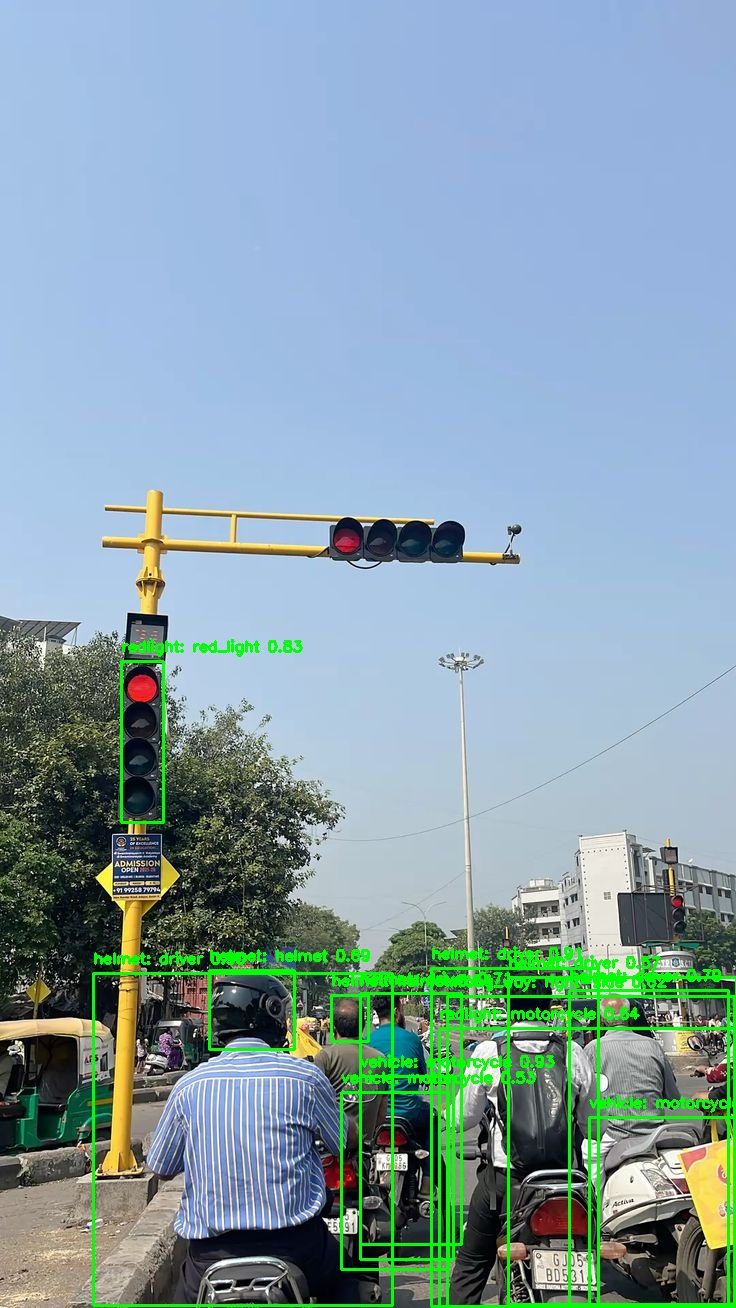

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

# Run full detection
output = full_detection(filename)

# Show evidence image correctly
from IPython.display import Image as IPImage
import os

# Get latest evidence image
evidence_files = [f for f in os.listdir(evidence_path) if f.endswith('.jpg')]
latest = sorted(evidence_files)[-1]

print(f"\n📸 Showing evidence image:")
IPImage(f'{evidence_path}/{latest}')

In [ ]:
import cv2
import numpy as np
from datetime import datetime
import json
import os

# ============================================
# 1. PEAK HOUR DETECTION
# ============================================
def check_peak_hour():
    current_hour = datetime.now().hour

    if 8 <= current_hour <= 10:
        return True, "🔴 MORNING PEAK (8AM-10AM)"
    elif 17 <= current_hour <= 20:
        return True, "🔴 EVENING PEAK (5PM-8PM)"
    else:
        return False, "🟢 NORMAL HOURS"

# ============================================
# 2. WEATHER DETECTION
# ============================================
def detect_weather(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    contrast = np.std(gray)

    if brightness < 50:
        return "🌙 NIGHT", True
    elif brightness < 100 and contrast < 40:
        return "🌧️ RAINY/FOGGY", True
    elif contrast < 30:
        return "🌫️ FOGGY", True
    else:
        return "☀️ CLEAR", False

# ============================================
# 3. SPEED ESTIMATION
# ============================================
def estimate_speed(box_size_current, box_size_previous=None):
    if box_size_previous is None:
        return "Unable to estimate (need 2 frames)"

    size_change = abs(box_size_current - box_size_previous)

    if size_change > 50:
        speed = "🔴 HIGH SPEED (>60 kmph)"
        is_speeding = True
    elif size_change > 20:
        speed = "🟡 MEDIUM SPEED (30-60 kmph)"
        is_speeding = False
    else:
        speed = "🟢 LOW SPEED (<30 kmph)"
        is_speeding = False

    return speed, is_speeding

# ============================================
# 4. VIOLATION STATISTICS
# ============================================
def generate_statistics():
    evidence_files = [f for f in os.listdir(evidence_path)
                     if f.endswith('.json')]

    stats = {
        'total_reports': 0,
        'total_violations': 0,
        'violation_counts': {},
        'severity_counts': {
            'CRITICAL': 0,
            'HIGH': 0,
            'MEDIUM': 0,
            'LOW': 0
        },
        'peak_hour_violations': 0,
        'normal_hour_violations': 0
    }

    for file in evidence_files:
        with open(f'{evidence_path}/{file}', 'r') as f:
            report = json.load(f)

        stats['total_reports'] += 1
        stats['total_violations'] += len(report.get('violations', []))

        for v in report.get('violations', []):
            vtype = v['type']
            if vtype not in stats['violation_counts']:
                stats['violation_counts'][vtype] = 0
            stats['violation_counts'][vtype] += 1

            severity = v.get('severity', '')
            if 'CRITICAL' in severity:
                stats['severity_counts']['CRITICAL'] += 1
            elif 'HIGH' in severity:
                stats['severity_counts']['HIGH'] += 1
            elif 'MEDIUM' in severity:
                stats['severity_counts']['MEDIUM'] += 1
            else:
                stats['severity_counts']['LOW'] += 1

    return stats

# ============================================
# UPDATED FULL DETECTION WITH ALL FEATURES
# ============================================
def full_detection_v2(image_path):
    print("🔍 Running GuardianEye Detection...\n")

    # Check peak hour
    is_peak, peak_status = check_peak_hour()
    print(f"⏰ Time Status: {peak_status}")

    # Check weather
    weather, bad_weather = detect_weather(image_path)
    print(f"🌤️ Weather: {weather}")

    # Run violation detection
    violations, evidence_img = detect_violations(image_path)
    plates = read_license_plate(image_path)

    # Check repeat offenders
    for plate in plates:
        for v in violations:
            check_repeat_offender(plate, v['type'])

    # Calculate total score
    total_score = sum(v['score'] for v in violations)

    # Increase score during peak hours or bad weather
    if is_peak:
        total_score = int(total_score * 1.2)
        print("⚠️ Score increased 20% due to peak hours!")

    if bad_weather:
        total_score = int(total_score * 1.3)
        print("⚠️ Score increased 30% due to bad weather!")

    # Overall severity
    if total_score >= 20:
        overall = "🔴 CRITICAL"
    elif total_score >= 10:
        overall = "🟠 HIGH"
    elif total_score >= 5:
        overall = "🟡 MEDIUM"
    else:
        overall = "🟢 LOW"

    # Generate statistics
    stats = generate_statistics()

    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "peak_hour": peak_status,
        "weather": weather,
        "total_score": total_score,
        "overall_severity": overall,
        "violations": violations,
        "license_plates": plates,
        "alert_sent": True,
        "statistics": stats
    }

    # Save JSON
    json_path = f'{evidence_path}/report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)

    # Print report
    print(f"\n📊 GUARDIAN EYE REPORT")
    print("="*40)
    print(f"📅 Time: {output['timestamp']}")
    print(f"📍 Location: {output['location']}")
    print(f"⏰ Peak Hour: {peak_status}")
    print(f"🌤️ Weather: {weather}")
    print(f"\n🚨 Violations: {len(violations)}")
    for v in violations:
        print(f"→ {v['type'].upper()}: {v['class']} | Score: {v['score']}/10 | {v['severity']}")
    print(f"\n🎯 Total Score: {total_score}")
    print(f"⚠️ Severity: {overall}")
    print(f"🔢 Plates: {plates}")
    print(f"\n📈 STATISTICS:")
    print(f"→ Total Reports: {stats['total_reports']}")
    print(f"→ Total Violations: {stats['total_violations']}")
    print(f"→ By Type: {stats['violation_counts']}")
    print(f"→ By Severity: {stats['severity_counts']}")
    print("="*40)

    return output

print("✅ All 4 features ready!")

✅ All 4 features ready!


In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

# Run FULL detection with all features!
output = full_detection_v2(filename)

# Show evidence image
from IPython.display import Image as IPImage
import os

evidence_files = [f for f in os.listdir(evidence_path) if f.endswith('.jpg')]
latest = sorted(evidence_files)[-1]
IPImage(f'{evidence_path}/{latest}')

Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg
🔍 Running GuardianEye Detection...

⏰ Time Status: 🟢 NORMAL HOURS
🌤️ Weather: ☀️ CLEAR

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 5 drivers, 2 helmets, 152.1ms
Speed: 3.5ms preprocess, 152.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 155.1ms
Speed: 2.7ms preprocess, 155.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 137.5ms
Speed: 2.7ms preprocess, 137.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 150.2ms
Speed: 3.0ms preprocess, 150.2

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 27
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 28
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 29
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 30
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 31
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 32
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 33
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 34
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 35
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 36
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 37
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 38
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 39


AttributeError: 'list' object has no attribute 'get'

In [ ]:
def generate_statistics():
    evidence_files = [f for f in os.listdir(evidence_path)
                     if f.endswith('.json')]

    stats = {
        'total_reports': 0,
        'total_violations': 0,
        'violation_counts': {},
        'severity_counts': {
            'CRITICAL': 0,
            'HIGH': 0,
            'MEDIUM': 0,
            'LOW': 0
        }
    }

    for file in evidence_files:
        try:
            with open(f'{evidence_path}/{file}', 'r') as f:
                report = json.load(f)

            stats['total_reports'] += 1

            # Handle both list and dict format
            if isinstance(report, dict):
                violations = report.get('violations', [])
            elif isinstance(report, list):
                violations = report
            else:
                continue

            stats['total_violations'] += len(violations)

            for v in violations:
                if isinstance(v, dict):
                    vtype = v.get('type', 'unknown')
                    if vtype not in stats['violation_counts']:
                        stats['violation_counts'][vtype] = 0
                    stats['violation_counts'][vtype] += 1

                    severity = v.get('severity', '')
                    if 'CRITICAL' in severity:
                        stats['severity_counts']['CRITICAL'] += 1
                    elif 'HIGH' in severity:
                        stats['severity_counts']['HIGH'] += 1
                    elif 'MEDIUM' in severity:
                        stats['severity_counts']['MEDIUM'] += 1
                    else:
                        stats['severity_counts']['LOW'] += 1
        except:
            continue

    return stats

print("✅ Statistics fixed!")

✅ Statistics fixed!


In [ ]:
output = full_detection_v2(filename)

🔍 Running GuardianEye Detection...

⏰ Time Status: 🟢 NORMAL HOURS
🌤️ Weather: ☀️ CLEAR

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 5 drivers, 2 helmets, 434.7ms
Speed: 15.6ms preprocess, 434.7ms inference, 8.4ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 620.2ms
Speed: 8.9ms preprocess, 620.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 499.9ms
Speed: 8.1ms preprocess, 499.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 636.1ms
Speed: 8.2ms preprocess, 636.1ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/WhatsApp Image 2026-06-17 at 10.41.09 PM (4).jpeg: 640x384 (no detections), 207

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 40
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 41
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 42
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 43
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 44
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 45
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 46
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 47
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 48
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 49
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 50
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 51
🚨 REPEAT OFFENDER! Plate: BD5314 | Violations: 52

📊 GUARDIAN EYE REPORT
📅 Time: 2026-06-18 06:48:46
📍 Location: Delhi, India
⏰ Peak Hour: 🟢 NORMAL HOURS
🌤️ Weather: ☀️ CLEAR

🚨 Violations: 13
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW


In [ ]:
# Reset offender file for clean demo
import json
with open(offender_file, 'w') as f:
    json.dump({}, f)
print("✅ Offender file reset!")

✅ Offender file reset!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 550.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 17.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

models_path = '/content/drive/MyDrive/GuardianEye/models'

models = {
    'helmet': YOLO(f'{models_path}/helmet_model/weights/best.pt'),
    'illegal_parking': YOLO(f'{models_path}/illegal_parking_model/weights/best.pt'),
    'license_plate': YOLO(f'{models_path}/license_plate_model/weights/best.pt'),
    'seatbelt': YOLO(f'{models_path}/seatbelt_model/weights/best.pt'),
    'stopline': YOLO(f'{models_path}/stopline_model/weights/best.pt'),
    'redlight': YOLO(f'{models_path}/redlight_model/weights/best.pt'),
    'triple_ride': YOLO(f'{models_path}/triple_ride_model/weights/best.pt'),
    'vehicle': YOLO(f'{models_path}/vehicle_model/weights/best.pt'),
    'wrong_way': YOLO(f'{models_path}/wrong_way_model/weights/best.pt'),
}
print("✅ Models loaded!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Models loaded!


In [ ]:
import cv2
import os
import json
import easyocr
import numpy as np
from datetime import datetime

reader = easyocr.Reader(['en'])
evidence_path = '/content/drive/MyDrive/GuardianEye/evidence'
offender_file = '/content/drive/MyDrive/GuardianEye/offenders.json'
os.makedirs(evidence_path, exist_ok=True)

violation_scores = {
    'helmet': {'no-helmet': 8, 'helmet': 0, 'driver': 5},
    'accident': {'Accident': 10, 'Non Accident': 0},
    'illegal_parking': {'illegal-parking': 4},
    'seatbelt': {'no-seatbelt': 7, 'seatbelt': 0},
    'stopline': {'stop-line': 6},
    'redlight': {'red_light': 9, 'motorcycle': 5},
    'triple_ride': {'triple-ride': 8},
    'vehicle': {'motorcycle': 3, 'car': 3, 'truck': 3},
    'wrong_way': {'wrong-side': 10, 'right-side': 0}
}

def get_severity_label(score):
    if score >= 9:
        return "🔴 CRITICAL"
    elif score >= 7:
        return "🟠 HIGH"
    elif score >= 4:
        return "🟡 MEDIUM"
    else:
        return "🟢 LOW"

def check_repeat_offender(plate_number, violation_type):
    if os.path.exists(offender_file):
        with open(offender_file, 'r') as f:
            offenders = json.load(f)
    else:
        offenders = {}
    if plate_number not in offenders:
        offenders[plate_number] = []
    offenders[plate_number].append({
        'violation': violation_type,
        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    })
    with open(offender_file, 'w') as f:
        json.dump(offenders, f, indent=4)
    count = len(offenders[plate_number])
    if count >= 3:
        print(f"🚨 REPEAT OFFENDER! Plate: {plate_number} | Violations: {count}")
        return True, count
    else:
        print(f"✅ Plate: {plate_number} | Violations: {count}/3")
        return False, count

def detect_violations(image_path):
    image = cv2.imread(image_path)
    violations = []
    for model_name, model in models.items():
        results = model(image_path, conf=0.5)
        for result in results:
            if result.boxes is not None and len(result.boxes) > 0:
                for box in result.boxes:
                    confidence = float(box.conf[0])
                    class_id = int(box.cls[0])
                    class_name = result.names[class_id]
                    score = violation_scores.get(model_name, {}).get(class_name, 3)
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
                    cv2.putText(image,
                        f'{model_name}: {class_name} {confidence:.2f}',
                        (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0,255,0), 2)
                    violations.append({
                        'type': model_name,
                        'class': class_name,
                        'confidence': round(confidence, 2),
                        'score': score,
                        'severity': get_severity_label(score),
                        'time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                    })
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    evidence_img = f'{evidence_path}/violation_{timestamp}.jpg'
    cv2.imwrite(evidence_img, image)
    return violations, evidence_img

def read_license_plate(image_path):
    results = reader.readtext(image_path)
    plates = []
    for (bbox, text, confidence) in results:
        if confidence > 0.3:
            plates.append(text)
    return plates

def generate_statistics():
    evidence_files = [f for f in os.listdir(evidence_path) if f.endswith('.json')]
    stats = {
        'total_reports': 0,
        'total_violations': 0,
        'violation_counts': {},
        'severity_counts': {'CRITICAL': 0, 'HIGH': 0, 'MEDIUM': 0, 'LOW': 0}
    }
    for file in evidence_files:
        try:
            with open(f'{evidence_path}/{file}', 'r') as f:
                report = json.load(f)
            stats['total_reports'] += 1
            violations = report.get('violations', []) if isinstance(report, dict) else report
            stats['total_violations'] += len(violations)
            for v in violations:
                if isinstance(v, dict):
                    vtype = v.get('type', 'unknown')
                    if vtype not in stats['violation_counts']:
                        stats['violation_counts'][vtype] = 0
                    stats['violation_counts'][vtype] += 1
                    severity = v.get('severity', '')
                    if 'CRITICAL' in severity:
                        stats['severity_counts']['CRITICAL'] += 1
                    elif 'HIGH' in severity:
                        stats['severity_counts']['HIGH'] += 1
                    elif 'MEDIUM' in severity:
                        stats['severity_counts']['MEDIUM'] += 1
                    else:
                        stats['severity_counts']['LOW'] += 1
        except:
            continue
    return stats

def check_peak_hour():
    current_hour = datetime.now().hour
    if 8 <= current_hour <= 10:
        return True, "🔴 MORNING PEAK (8AM-10AM)"
    elif 17 <= current_hour <= 20:
        return True, "🔴 EVENING PEAK (5PM-8PM)"
    else:
        return False, "🟢 NORMAL HOURS"

def detect_weather(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    contrast = np.std(gray)
    if brightness < 50:
        return "🌙 NIGHT", True
    elif brightness < 100 and contrast < 40:
        return "🌧️ RAINY/FOGGY", True
    elif contrast < 30:
        return "🌫️ FOGGY", True
    else:
        return "☀️ CLEAR", False

def full_detection_v2(image_path):
    print("🔍 Running GuardianEye Detection...\n")
    is_peak, peak_status = check_peak_hour()
    print(f"⏰ Time Status: {peak_status}")
    weather, bad_weather = detect_weather(image_path)
    print(f"🌤️ Weather: {weather}")
    violations, evidence_img = detect_violations(image_path)
    plates = read_license_plate(image_path)
    for plate in plates:
        for v in violations:
            check_repeat_offender(plate, v['type'])
    total_score = sum(v['score'] for v in violations)
    if is_peak:
        total_score = int(total_score * 1.2)
    if bad_weather:
        total_score = int(total_score * 1.3)
    if total_score >= 20:
        overall = "🔴 CRITICAL"
    elif total_score >= 10:
        overall = "🟠 HIGH"
    elif total_score >= 5:
        overall = "🟡 MEDIUM"
    else:
        overall = "🟢 LOW"
    stats = generate_statistics()
    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "peak_hour": peak_status,
        "weather": weather,
        "total_score": total_score,
        "overall_severity": overall,
        "violations": violations,
        "license_plates": plates,
        "alert_sent": True,
        "statistics": stats
    }
    json_path = f'{evidence_path}/report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)
    print(f"\n📊 GUARDIAN EYE REPORT")
    print("="*40)
    for v in violations:
        print(f"→ {v['type'].upper()}: {v['class']} | Score: {v['score']}/10 | {v['severity']}")
    print(f"\n🎯 Total Score: {total_score}")
    print(f"⚠️ Overall: {overall}")
    print(f"🔢 Plates: {plates}")
    print(f"🚔 Alert Sent: True")
    print("="*40)
    return output

print("✅ All functions ready!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ All functions ready!


In [ ]:
def preprocess_image(image_path):
    print("🔧 Preprocessing image...")

    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Check image conditions
    brightness = np.mean(gray)
    contrast = np.std(gray)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    print(f"📊 Original stats:")
    print(f"→ Brightness: {brightness:.1f}")
    print(f"→ Contrast: {contrast:.1f}")
    print(f"→ Blur score: {blur_score:.1f}")

    # STEP 1 - Enhance contrast (CLAHE)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    image = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    print("✅ Contrast enhanced!")

    # STEP 2 - Fix low light
    if brightness < 100:
        print("🌙 Low light detected - fixing...")
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        v = cv2.add(v, 50)
        hsv = cv2.merge((h,s,v))
        image = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
        print("✅ Low light fixed!")

    # STEP 3 - Fix fog/rain
    if contrast < 40:
        print("🌧️ Fog/rain detected - fixing...")
        image = cv2.convertScaleAbs(image, alpha=1.5, beta=30)
        print("✅ Fog/rain fixed!")

    # STEP 4 - Fix motion blur
    if blur_score < 100:
        print("💨 Blur detected - fixing...")
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])
        image = cv2.filter2D(image, -1, kernel)
        print("✅ Blur fixed!")

    # STEP 5 - Remove noise
    image = cv2.fastNlMeansDenoisingColored(
        image, None, 10, 10, 7, 21
    )
    print("✅ Noise removed!")

    # Save preprocessed image
    preprocessed_path = '/content/preprocessed_image.jpg'
    cv2.imwrite(preprocessed_path, image)

    # Check improved stats
    gray_new = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(f"\n📊 After preprocessing:")
    print(f"→ Brightness: {np.mean(gray_new):.1f}")
    print(f"→ Contrast: {np.std(gray_new):.1f}")
    print(f"→ Blur score: {cv2.Laplacian(gray_new, cv2.CV_64F).var():.1f}")

    return preprocessed_path

# Update full detection to use preprocessing!
def full_detection_v3(image_path):
    print("🔍 Running GuardianEye V3...\n")

    # PREPROCESS FIRST!
    preprocessed_path = preprocess_image(image_path)
    print("\n")

    # Then run detection on preprocessed image
    is_peak, peak_status = check_peak_hour()
    print(f"⏰ Time: {peak_status}")

    weather, bad_weather = detect_weather(preprocessed_path)
    print(f"🌤️ Weather: {weather}")

    violations, evidence_img = detect_violations(preprocessed_path)
    plates = read_license_plate(preprocessed_path)

    for plate in plates:
        for v in violations:
            check_repeat_offender(plate, v['type'])

    total_score = sum(v['score'] for v in violations)

    if is_peak:
        total_score = int(total_score * 1.2)
    if bad_weather:
        total_score = int(total_score * 1.3)

    if total_score >= 20:
        overall = "🔴 CRITICAL"
    elif total_score >= 10:
        overall = "🟠 HIGH"
    elif total_score >= 5:
        overall = "🟡 MEDIUM"
    else:
        overall = "🟢 LOW"

    stats = generate_statistics()

    output = {
        "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "camera_id": "CAM_001",
        "location": "Delhi, India",
        "peak_hour": peak_status,
        "weather": weather,
        "total_score": total_score,
        "overall_severity": overall,
        "violations": violations,
        "license_plates": plates,
        "alert_sent": True,
        "statistics": stats,
        "preprocessed": True
    }

    json_path = f'{evidence_path}/report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
    with open(json_path, 'w') as f:
        json.dump(output, f, indent=4)

    print(f"\n📊 GUARDIAN EYE V3 REPORT")
    print("="*40)
    for v in violations:
        print(f"→ {v['type'].upper()}: {v['class']} | Score: {v['score']}/10 | {v['severity']}")
    print(f"\n🎯 Total Score: {total_score}")
    print(f"⚠️ Overall: {overall}")
    print(f"🔢 Plates: {plates}")
    print(f"🚔 Alert Sent: True")
    print(f"🔧 Preprocessed: Yes ✅")
    print("="*40)

    return output

print("✅ Preprocessing + V3 Detection ready!")

✅ Preprocessing + V3 Detection ready!


In [ ]:
def evaluate_performance(image_path, ground_truth_violations):
    """
    ground_truth_violations = what violations
    actually exist in image (manual input)
    """
    print("📊 Evaluating Performance...\n")

    # Run detection
    violations, evidence_img = detect_violations(image_path)

    # Get predicted classes
    predicted = [v['type'] for v in violations]
    actual = ground_truth_violations

    # Calculate metrics
    true_positives = len([p for p in predicted if p in actual])
    false_positives = len([p for p in predicted if p not in actual])
    false_negatives = len([a for a in actual if a not in predicted])

    # Precision
    precision = true_positives / (true_positives + false_positives) \
        if (true_positives + false_positives) > 0 else 0

    # Recall
    recall = true_positives / (true_positives + false_negatives) \
        if (true_positives + false_negatives) > 0 else 0

    # F1 Score
    f1 = 2 * (precision * recall) / (precision + recall) \
        if (precision + recall) > 0 else 0

    # Accuracy
    total = true_positives + false_positives + false_negatives
    accuracy = true_positives / total if total > 0 else 0

    # mAP (average confidence of correct detections)
    correct_detections = [v for v in violations if v['type'] in actual]
    mAP = np.mean([v['confidence'] for v in correct_detections]) \
        if correct_detections else 0

    metrics = {
        'accuracy': round(accuracy * 100, 2),
        'precision': round(precision * 100, 2),
        'recall': round(recall * 100, 2),
        'f1_score': round(f1 * 100, 2),
        'mAP': round(mAP * 100, 2),
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }

    print("📈 PERFORMANCE METRICS:")
    print("="*40)
    print(f"✅ Accuracy:  {metrics['accuracy']}%")
    print(f"✅ Precision: {metrics['precision']}%")
    print(f"✅ Recall:    {metrics['recall']}%")
    print(f"✅ F1 Score:  {metrics['f1_score']}%")
    print(f"✅ mAP:       {metrics['mAP']}%")
    print("="*40)
    print(f"→ True Positives:  {true_positives}")
    print(f"→ False Positives: {false_positives}")
    print(f"→ False Negatives: {false_negatives}")
    print("="*40)

    # Save metrics
    metrics_path = f'{evidence_path}/metrics.json'
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)

    print("✅ Metrics saved to Drive!")

    return metrics

print("✅ Performance evaluation ready!")

✅ Performance evaluation ready!


Saving WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg to WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg
✅ Uploaded: WhatsApp Image 2026-06-17 at 10.41.09 PM.jpeg
🔍 Running GuardianEye V3...

🔧 Preprocessing image...
📊 Original stats:
→ Brightness: 150.6
→ Contrast: 61.5
→ Blur score: 2875.7
✅ Contrast enhanced!
✅ Noise removed!

📊 After preprocessing:
→ Brightness: 154.9
→ Contrast: 55.4
→ Blur score: 4025.3


⏰ Time: 🔴 MORNING PEAK (8AM-10AM)
🌤️ Weather: ☀️ CLEAR

image 1/1 /content/preprocessed_image.jpg: 640x384 5 drivers, 2 helmets, 1 no-helmet, 314.8ms
Speed: 14.8ms preprocess, 314.8ms inference, 38.0ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/preprocessed_image.jpg: 640x384 (no detections), 111.1ms
Speed: 2.3ms preprocess, 111.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/preprocessed_image.jpg: 640x384 (no detections), 107.3ms
Speed: 2.0ms preprocess, 107.3ms inference, 0.5ms postprocess per image at shape (1, 3

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Plate: 88 | Violations: 1/3
✅ Plate: 88 | Violations: 2/3
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 3
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 4
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 5
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 6
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 7
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 8
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 9
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 10
🚨 REPEAT OFFENDER! Plate: 88 | Violations: 11

📊 GUARDIAN EYE V3 REPORT
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ HELMET: helmet | Score: 0/10 | 🟢 LOW
→ HELMET: driver | Score: 5/10 | 🟡 MEDIUM
→ HELMET: no-helmet | Score: 8/10 | 🟠 HIGH
→ REDLIGHT: motorcycle | Score: 5/10 | 🟡 MEDIUM
→ REDLIGHT: red_light | Score: 9/10 | 🔴 CRITICAL
→ VEHICLE: motorcycle | Score: 3/10 | 🟢 LOW

🎯 Total Score: 60
⚠️ Overall: 🔴 CR

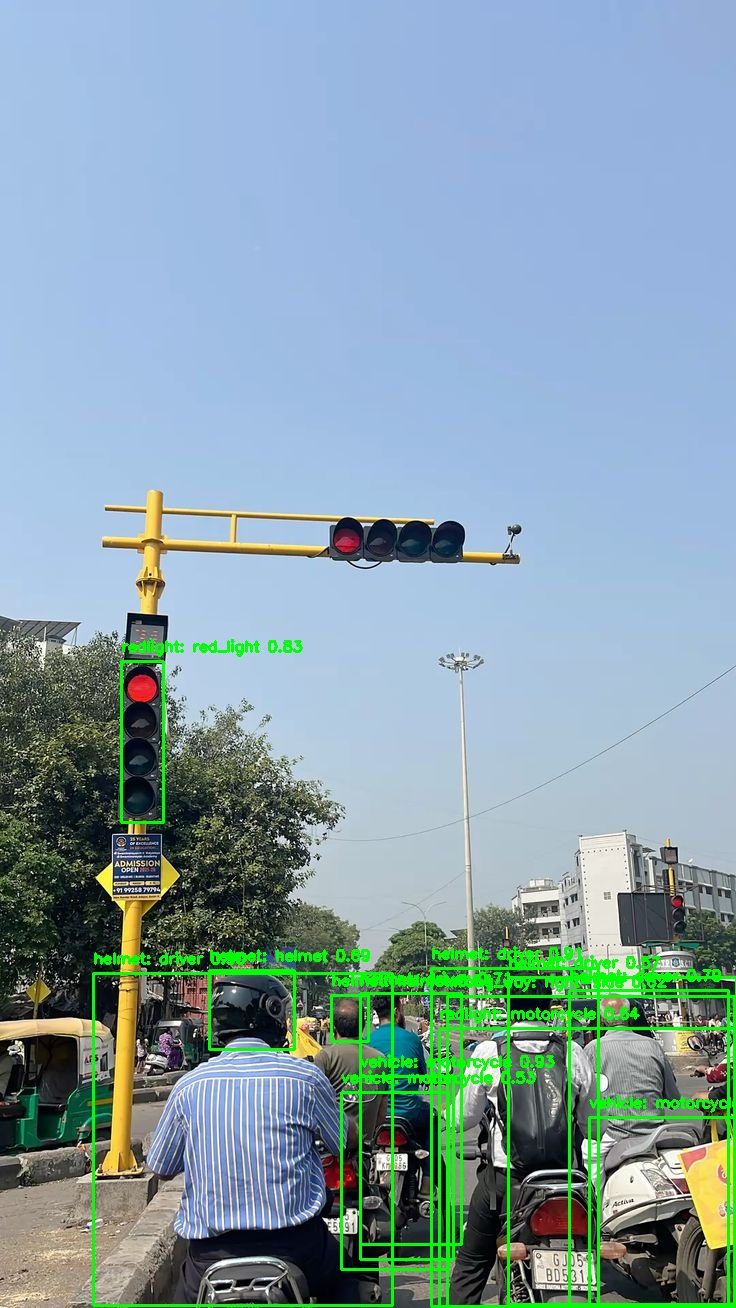

In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

# Tell system what violations actually exist in image
# Change these based on your uploaded image!
ground_truth = ['helmet', 'vehicle', 'redlight']

# Run V3 full detection
output = full_detection_v3(filename)

# Run performance evaluation
metrics = evaluate_performance(filename, ground_truth)

# Show evidence image
from IPython.display import Image as IPImage
import os

evidence_files = [f for f in os.listdir(evidence_path)
                 if f.endswith('.jpg')]
latest = sorted(evidence_files)[-1]
IPImage(f'{evidence_path}/{latest}')

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KgbUcHtt4x7sYlFEfxg8")
ws = "deepeshs-workspace-blpt1"

datasets = [
    "helmet-detection-ntbfz-ewe7m",
    "traffic-red-light-violation-izf63-fmlpo",
    "vehicle-detection-eckrb-gtemm",
    "wrong-way-driving-detection-wemhn",
    "seatbelt-detection-lb1ec-3jgks",
    "illegal-parking-detection-unrl5",
    "triple-ride-detection-jscpe",
    "stop-line-jzmgr",
    "indian-license-plate-knte7-cnedq",
    "accident-detection-uaotj-9hhe4",
]

for dataset in datasets:
    print(f"📥 Downloading {dataset}...")
    try:
        project = rf.workspace(ws).project(dataset)
        version = project.version(1)
        version.download("yolov8")
        print(f"✅ Done!")
    except Exception as e:
        print(f"❌ Error: {e}")

print("\n🎉 All datasets downloaded!")

📥 Downloading helmet-detection-ntbfz-ewe7m...
loading Roboflow workspace...
loading Roboflow project...
✅ Done!
📥 Downloading traffic-red-light-violation-izf63-fmlpo...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Red-Light-Violation-1 in yolov8:: 100%|██████████| 5820/5820 [00:01<00:00, 3097.02it/s]


✅ Done!
📥 Downloading vehicle-detection-eckrb-gtemm...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicle-detection-1 in yolov8:: 100%|██████████| 5486/5486 [00:01<00:00, 3730.85it/s]


✅ Done!
📥 Downloading wrong-way-driving-detection-wemhn...
loading Roboflow workspace...
loading Roboflow project...


...

✅ Done!
📥 Downloading indian-license-plate-knte7-cnedq...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Indian-License-Plate-1 in yolov8:: 100%|██████████| 3304/3304 [00:00<00:00, 6831.82it/s]

✅ Done!
📥 Downloading accident-detection-uaotj-9hhe4...
loading Roboflow workspace...


loading Roboflow project...
❌ Error: {"error":"yolov8 is an invalid format for project type classification. Please use one of: folder, clip."}

🎉 All datasets downloaded!
